6で作成したチャープ信号のメルスペクトログラムを，
横軸時間 [s]，縦軸メル周波数としてプロットしなさい．
ただし，窓は $N = 1024$ 点のハン窓，ホップ長は $H = 512$ 点，
メル周波数ビン数は $n_\mathrm{mels} = 80$ とする．

In [1]:
from pathlib import Path
import numpy as np
import soundfile as sf

output_dir = Path("outputs/audio")
output_dir.mkdir(parents=True, exist_ok=True)

fs = 16000
T = 5.0
f0 = 100.0
f1 = 4000.0
amplitude = 0.5
k = (f1 - f0) / T

chirp_path = output_dir / "06_chirp_100_to_4000hz.wav"

if chirp_path.exists():
    x, sr = sf.read(chirp_path, dtype="float32")
    fs = sr
else:
    t = np.arange(int(fs * T)) / fs
    x = amplitude * np.sin(2 * np.pi * (f0 * t + 0.5 * k * t**2))
    sf.write(chirp_path, x, fs)

print(f"使用する音声: {chirp_path}")
print(f"fs = {fs} Hz")
print(f"samples = {len(x)}")
print(f"duration = {len(x) / fs:.2f} s")


使用する音声: outputs/audio/06_chirp_100_to_4000hz.wav
fs = 16000 Hz
samples = 80000
duration = 5.00 s


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path

figure_dir = Path("outputs/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

n_fft = 1024
hop_length = 512
n_mels = 80

mel = librosa.feature.melspectrogram(
    y=x.astype(float),
    sr=fs,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    power=2.0,
)

mel_db = librosa.power_to_db(mel, ref=np.max)

print(f"mel spectrogram shape: {mel.shape}")
print(f"mel bins: {mel.shape[0]}")
print(f"time frames: {mel.shape[1]}")


mel spectrogram shape: (80, 157)
mel bins: 80
time frames: 157


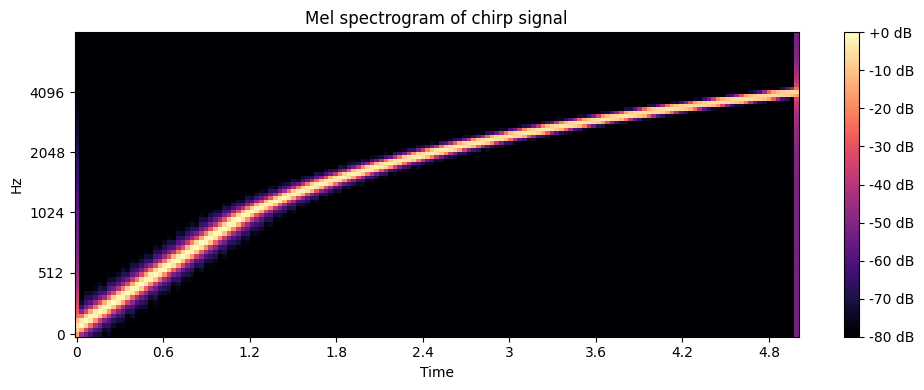

In [3]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel_db,
    sr=fs,
    hop_length=hop_length,
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel spectrogram of chirp signal")
plt.tight_layout()
plt.savefig(figure_dir / "09_chirp_mel_spectrogram.png", dpi=150)
plt.show()


メルスペクトログラムでは，周波数軸が人間の聴覚特性に近い非線形尺度になる．
高周波側では線形周波数軸より圧縮されて表示される．
